In [ ]:
# https://www.kaggle.com/datasets/mahmoudahmedmahrous/disaster-detection

import kagglehub

# Download latest version
path = kagglehub.dataset_download("mahmoudahmedmahrous/disaster-detection")

print("Path to dataset files:", path)

100%|██████████| 1.21G/1.21G [00:13<00:00, 96.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mahmoudahmedmahrous/disaster-detection/versions/1


In [ ]:
import os

base_dir = '/root/.cache/kagglehub/datasets/mahmoudahmedmahrous/disaster-detection/versions/1'
print(f"📁 Inside base_dir: {os.listdir(base_dir)}")

# Let's see what is inside the train folder (or whatever the first folder is)
# We will just grab the first item in the base directory to check it
first_item = os.listdir(base_dir)[0]
next_path = os.path.join(base_dir, first_item)

if os.path.isdir(next_path):
    print(f"📁 Inside '{first_item}': {os.listdir(next_path)}")

    # Let's go one level deeper just in case
    next_next_item = os.listdir(next_path)[0]
    next_next_path = os.path.join(next_path, next_next_item)
    if os.path.isdir(next_next_path):
        print(f"📁 Inside '{first_item}/{next_next_item}': {os.listdir(next_next_path)[:5]} (showing first 5)")

📁 Inside base_dir: ['valid', 'README.dataset.txt', 'train', 'test', 'README.roboflow.txt', 'data.yaml']
📁 Inside 'valid': ['collapsed_building', 'flood', 'traffic_incident', 'fire']
📁 Inside 'valid/collapsed_building': ['collapsed_building_image0141_3_png.rf.0236bbb219f13cd92c4b210414329e5c.jpg', 'collapsed_building_image0008_4_png.rf.50598dddab4db43fabacc9e032893e56.jpg', 'collapsed_building_image0430_4_png.rf.6c039fc91ecff4d40e74ea951d4c8c1b.jpg', 'collapsed_building_image0387_4_png.rf.5679629d21a4fdf77ab636b68718da8c.jpg', 'collapsed_building_image0499_3_png.rf.24d5f8feb0b374e8dffd9961f1e48b16.jpg'] (showing first 5)


In [ ]:
import os
import shutil

# 1. Define where your downloaded dataset lives
base_dir = '/root/.cache/kagglehub/datasets/mahmoudahmedmahrous/disaster-detection/versions/1'

# We need to clean up both the training data and validation data
splits_to_organize = ['train', 'valid']

print("🧹 Starting dataset cleanup...")

for split in splits_to_organize:
    # Set paths for the current split (e.g., .../train and .../train/images)
    split_dir = os.path.join(base_dir, split)
    images_dir = os.path.join(split_dir, 'images')

    # If there is no 'images' folder, it might have already been moved!
    if not os.path.exists(images_dir):
        print(f"⚠️ No 'images' folder found in {split_dir}. Skipping.")
        continue

    print(f"📦 Sorting {split} images into class folders...")

    # 2. Loop through every single image in the YOLO 'images' folder
    for filename in os.listdir(images_dir):

        # Make sure we only grab image files, just in case there are random hidden files
        if not filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue

        # 3. Extract the class name from the filename.
        # By splitting the text at '_image', 'fire_image123.jpg' becomes ['fire', '123.jpg']
        # We grab the first part [0] which gives us exactly the class label!
        class_name = filename.split('_image')[0]

        # 4. Create a folder for that specific class if it doesn't exist yet
        # e.g., .../train/fire/
        class_folder = os.path.join(split_dir, class_name)
        os.makedirs(class_folder, exist_ok=True)

        # 5. Move the image from the YOLO 'images' folder to our new PyTorch class folder
        src_path = os.path.join(images_dir, filename)
        dst_path = os.path.join(class_folder, filename)
        shutil.move(src_path, dst_path)

    print(f"✅ {split.capitalize()} images sorted successfully!")

print("\n🎉 All done! Your dataset is now ready for PyTorch ImageFolder.")

🧹 Starting dataset cleanup...
⚠️ No 'images' folder found in /root/.cache/kagglehub/datasets/mahmoudahmedmahrous/disaster-detection/versions/1/train. Skipping.
⚠️ No 'images' folder found in /root/.cache/kagglehub/datasets/mahmoudahmedmahrous/disaster-detection/versions/1/valid. Skipping.

🎉 All done! Your dataset is now ready for PyTorch ImageFolder.


In [ ]:
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'valid')

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(root=val_dir, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

print(f"Loaded {len(train_dataset)} training images and {len(val_dataset)} validation images.")

Loaded 20775 training images and 1963 validation images.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
import shutil
import os

base_dir = '/root/.cache/kagglehub/datasets/mahmoudahmedmahrous/disaster-detection/versions/1'

print("🧹 Cleaning up leftover YOLO folders...")

for split in ['train', 'valid']:
    split_dir = os.path.join(base_dir, split)

    # Target the old folders for deletion
    for old_folder in ['images', 'labels']:
        folder_path = os.path.join(split_dir, old_folder)

        if os.path.exists(folder_path):
            shutil.rmtree(folder_path) # Deletes the folder and anything left inside it
            print(f"🗑️ Deleted: {split}/{old_folder}")

print("✨ All clean! You can now run your PyTorch ImageFolder code.")

🧹 Cleaning up leftover YOLO folders...
✨ All clean! You can now run your PyTorch ImageFolder code.


In [ ]:
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'valid') # <-- Updated to 'valid' based on your logs

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(root=val_dir, transform=val_transforms)

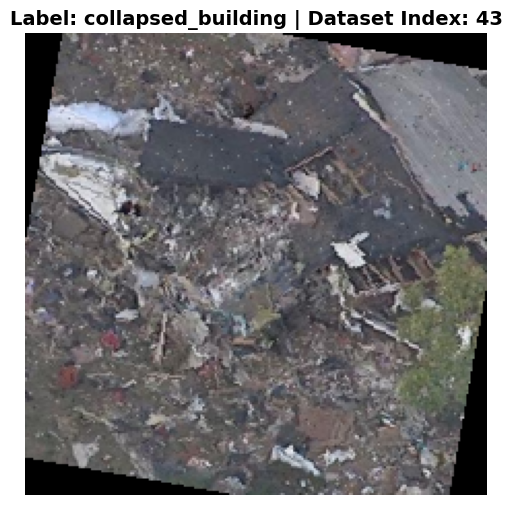

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def view_image(dataset, index):
    """
    Pulls a specific image from a PyTorch dataset and displays it.
    """
    # 1. Grab the image tensor and the numeric label from the dataset
    img_tensor, label_idx = dataset[index]

    # 2. Convert the numeric label back into a human-readable string (e.g., 'fire')
    class_name = dataset.classes[label_idx]

    # 3. Convert PyTorch tensor to a Numpy array
    # PyTorch uses (Channels, Height, Width), but Matplotlib expects (Height, Width, Channels)
    img_np = img_tensor.numpy().transpose((1, 2, 0))

    # 4. Undo the Normalization math so it looks like a normal picture again
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_unnormalized = std * img_np + mean

    # Clip values between 0 and 1 to fix any tiny mathematical rounding errors
    img_ready = np.clip(img_unnormalized, 0, 1)

    # 5. Display the image
    plt.figure(figsize=(6, 6))
    plt.imshow(img_ready)
    plt.title(f"Label: {class_name} | Dataset Index: {index}", fontsize=14, fontweight='bold')
    plt.axis('off') # Hides the gridlines and axes
    plt.show()

# ==========================================
# TEST IT OUT
# ==========================================
# Change the number below to view any image from 0 up to 20774
view_image(train_dataset, index=43)

In [ ]:
# ===============================================================
# 🧠 AI Disaster Classification (Master Pipeline)
# Model: MobileNetV2 + Strong Augmentation + Class Weights + Graphs
# ===============================================================

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from PIL import ImageFile
import matplotlib.pyplot as plt

# ✅ Handle potentially corrupted downloaded images
ImageFile.LOAD_TRUNCATED_IMAGES = True

# ==========================================
# 1. HARDWARE & PATHS
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Using device: {device}")

base_dir = '/root/.cache/kagglehub/datasets/mahmoudahmedmahrous/disaster-detection/versions/1'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'valid')

# ==========================================
# 2. DATA AUGMENTATION & LOADERS
# ==========================================
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(root=val_dir, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"📂 Loaded {len(train_dataset)} training images and {len(val_dataset)} validation images.")
print(f"🏷️ Classes detected: {train_dataset.classes}")

# ==========================================
# 3. CLASS WEIGHTS (Handling Imbalance)
# ==========================================
train_labels = train_dataset.targets
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# ==========================================
# 4. MODEL SETUP (MobileNetV2)
# ==========================================
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

num_classes = len(train_dataset.classes)
model.classifier[1] = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(model.last_channel, num_classes)
)
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# ==========================================
# 5. MANUAL TRAINING & VISUALIZATION TOOLS
# ==========================================

# Global variables to track history and the best model
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_loss = float('inf')

def train_epoch(epoch_number):
    """Run this function to train the model for one epoch."""
    print(f"\n🚀 --- TRAIN: Epoch {epoch_number} ---")
    model.train()
    running_loss, running_corrects = 0.0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = (running_corrects.double() / len(train_loader.dataset)).item()

    # Save to history for plotting
    history['train_loss'].append(epoch_loss)
    history['train_acc'].append(epoch_acc)

    print(f"📈 Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")

def validate_epoch(epoch_number):
    """Run this function to validate the model and save if it improves."""
    global best_loss
    print(f"\n🔬 --- VALIDATE: Epoch {epoch_number} ---")
    model.eval()
    val_loss, val_corrects = 0.0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    val_epoch_loss = val_loss / len(val_loader.dataset)
    val_epoch_acc = (val_corrects.double() / len(val_loader.dataset)).item()

    # Save to history for plotting
    history['val_loss'].append(val_epoch_loss)
    history['val_acc'].append(val_epoch_acc)

    print(f"📉 Val Loss:   {val_epoch_loss:.4f} | Val Acc:   {val_epoch_acc:.4f}")

    scheduler.step(val_epoch_loss)

    if val_epoch_loss < best_loss:
        best_loss = val_epoch_loss
        torch.save(model.state_dict(), 'best_disaster_model.pth')
        print("🌟 Validation loss improved! Model saved to 'best_disaster_model.pth'.")
    else:
        print("⚠️ No improvement in validation loss this epoch.")

def plot_metrics():
    """Generates two graphs: Loss over time, and Accuracy over time."""
    epochs_trained = range(1, len(history['train_loss']) + 1)
    epochs_validated = range(1, len(history['val_loss']) + 1)

    if len(epochs_trained) == 0:
        print("⚠️ No data to plot yet! Run train_epoch() first.")
        return

    plt.figure(figsize=(12, 5))

    # Graph 1: Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_trained, history['train_loss'], label='Train Loss', marker='o', color='blue')
    if len(epochs_validated) > 0:
        plt.plot(epochs_validated, history['val_loss'], label='Val Loss', marker='o', color='orange')
    plt.title('Loss over Epochs', fontsize=14)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # Graph 2: Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs_trained, history['train_acc'], label='Train Acc', marker='o', color='green')
    if len(epochs_validated) > 0:
        plt.plot(epochs_validated, history['val_acc'], label='Val Acc', marker='o', color='red')
    plt.title('Accuracy over Epochs', fontsize=14)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

print("\n✅ Master Setup Complete! You can now run train_epoch(n), validate_epoch(n), and plot_metrics().")

🖥️ Using device: cuda
📂 Loaded 20775 training images and 1963 validation images.
🏷️ Classes detected: ['collapsed_building', 'fire', 'flood', 'traffic_incident']

✅ Master Setup Complete! You can now run train_epoch(n), validate_epoch(n), and plot_metrics().


In [ ]:
train_epoch(1)


🚀 --- TRAIN: Epoch 1 ---
📈 Train Loss: 0.3178 | Train Acc: 0.8928


In [ ]:
validate_epoch(1)


🔬 --- VALIDATE: Epoch 1 ---
📉 Val Loss:   0.0796 | Val Acc:   0.9710
🌟 Validation loss improved! Model saved to 'best_disaster_model.pth'.


In [ ]:
train_epoch(2)


🚀 --- TRAIN: Epoch 2 ---
📈 Train Loss: 0.2173 | Train Acc: 0.9262


In [ ]:
validate_epoch(2)


🔬 --- VALIDATE: Epoch 2 ---
📉 Val Loss:   0.0744 | Val Acc:   0.9781
🌟 Validation loss improved! Model saved to 'best_disaster_model.pth'.


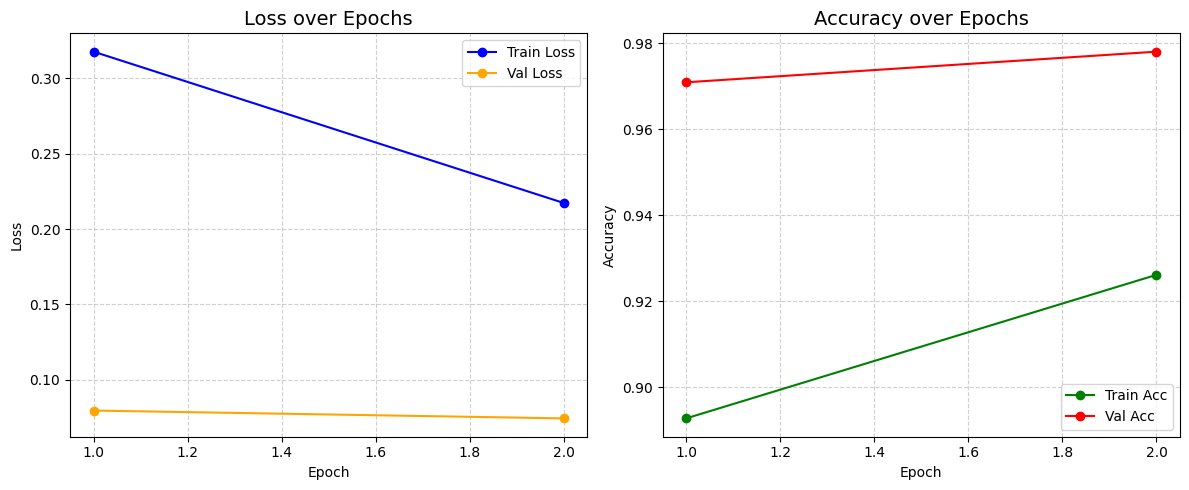

In [ ]:
plot_metrics()


🚀 --- TRAIN: Epoch 3 ---
📈 Train Loss: 0.1851 | Train Acc: 0.9390

🔬 --- VALIDATE: Epoch 3 ---
📉 Val Loss:   0.0402 | Val Acc:   0.9888
🌟 Validation loss improved! Model saved to 'best_disaster_model.pth'.


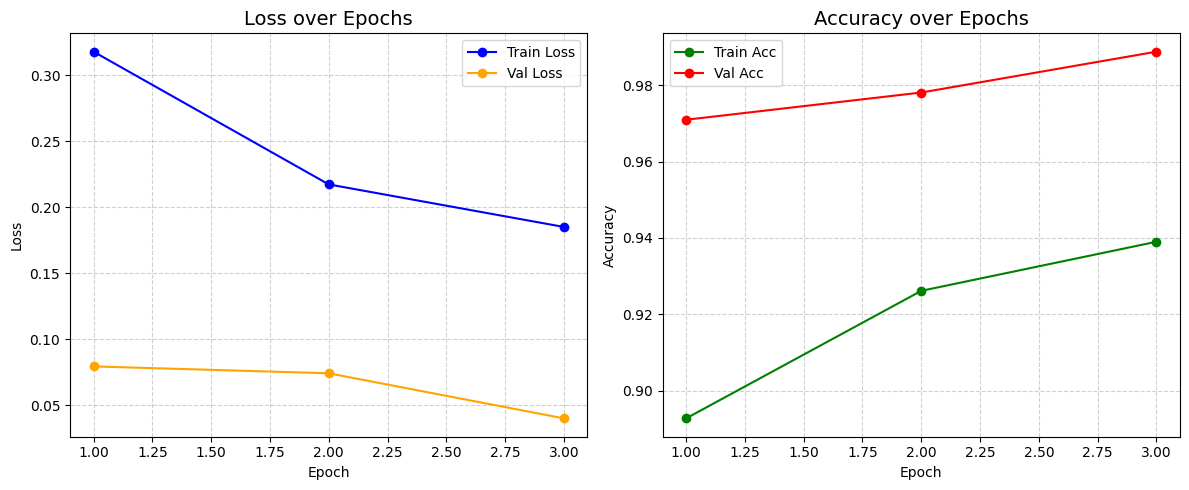

In [ ]:
train_epoch(3)
validate_epoch(3)
plot_metrics()


🚀 --- TRAIN: Epoch 4 ---
📈 Train Loss: 0.1603 | Train Acc: 0.9468

🔬 --- VALIDATE: Epoch 4 ---
📉 Val Loss:   0.0797 | Val Acc:   0.9689
⚠️ No improvement in validation loss this epoch.


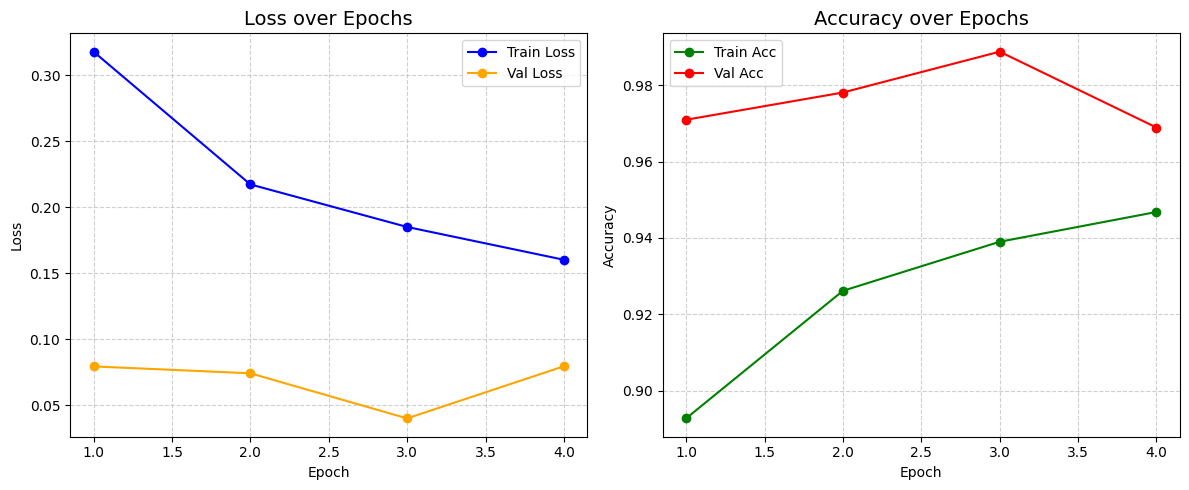

In [ ]:
train_epoch(4)
validate_epoch(4)
plot_metrics()


🚀 --- TRAIN: Epoch 5 ---
📈 Train Loss: 0.1530 | Train Acc: 0.9464

🔬 --- VALIDATE: Epoch 5 ---
📉 Val Loss:   0.0395 | Val Acc:   0.9847
🌟 Validation loss improved! Model saved to 'best_disaster_model.pth'.


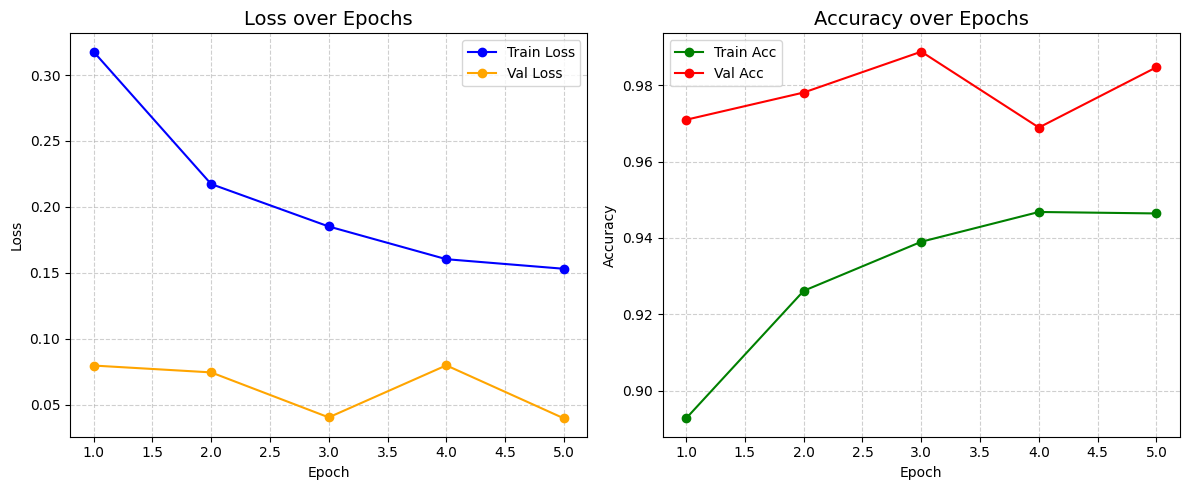

In [ ]:
train_epoch(5)
validate_epoch(5)
plot_metrics()


🚀 --- TRAIN: Epoch 6 ---
📈 Train Loss: 0.1485 | Train Acc: 0.9503

🔬 --- VALIDATE: Epoch 6 ---
📉 Val Loss:   0.0301 | Val Acc:   0.9903
🌟 Validation loss improved! Model saved to 'best_disaster_model.pth'.


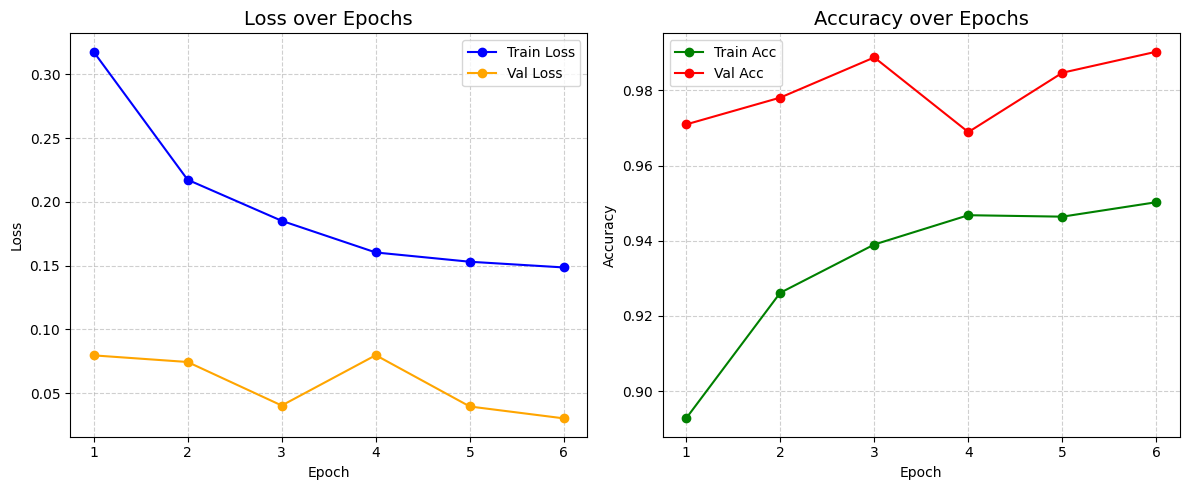

In [ ]:
train_epoch(6)
validate_epoch(6)
plot_metrics()


🚀 --- TRAIN: Epoch 7 ---
📈 Train Loss: 0.1306 | Train Acc: 0.9566

🔬 --- VALIDATE: Epoch 7 ---
📉 Val Loss:   0.0246 | Val Acc:   0.9924
🌟 Validation loss improved! Model saved to 'best_disaster_model.pth'.


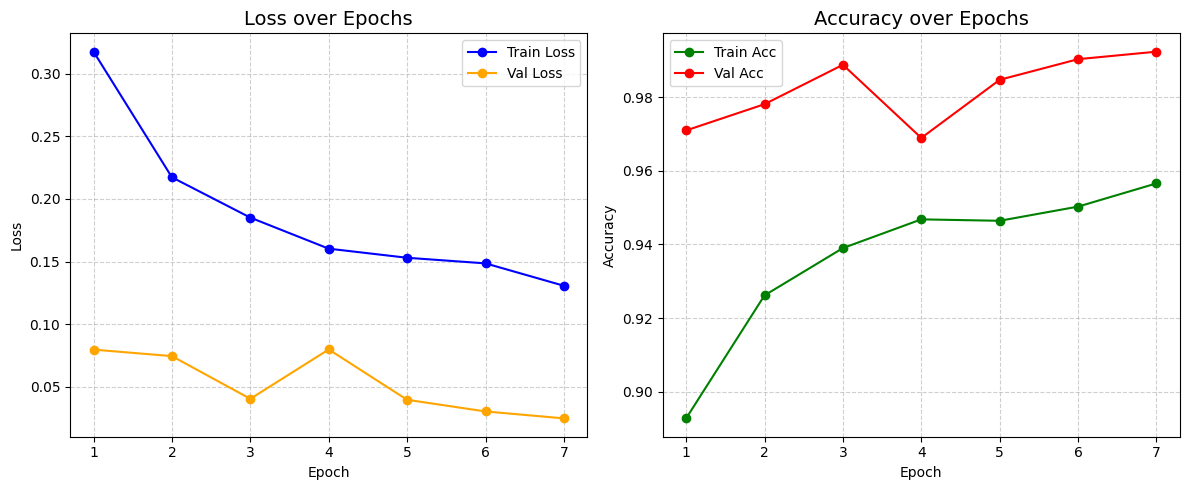

In [ ]:
train_epoch(7)
validate_epoch(7)
plot_metrics()


🚀 --- TRAIN: Epoch 8 ---
📈 Train Loss: 0.1291 | Train Acc: 0.9566

🔬 --- VALIDATE: Epoch 8 ---
📉 Val Loss:   0.0325 | Val Acc:   0.9893
⚠️ No improvement in validation loss this epoch.


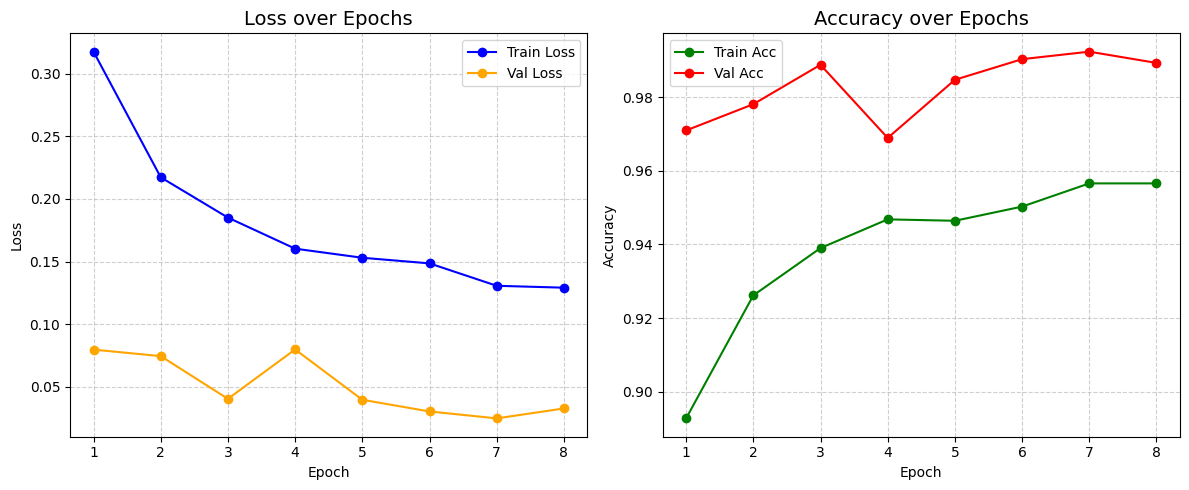

In [ ]:
train_epoch(8)
validate_epoch(8)
plot_metrics()


🚀 --- TRAIN: Epoch 9 ---
📈 Train Loss: 0.1251 | Train Acc: 0.9581

🔬 --- VALIDATE: Epoch 9 ---
📉 Val Loss:   0.0473 | Val Acc:   0.9827
⚠️ No improvement in validation loss this epoch.


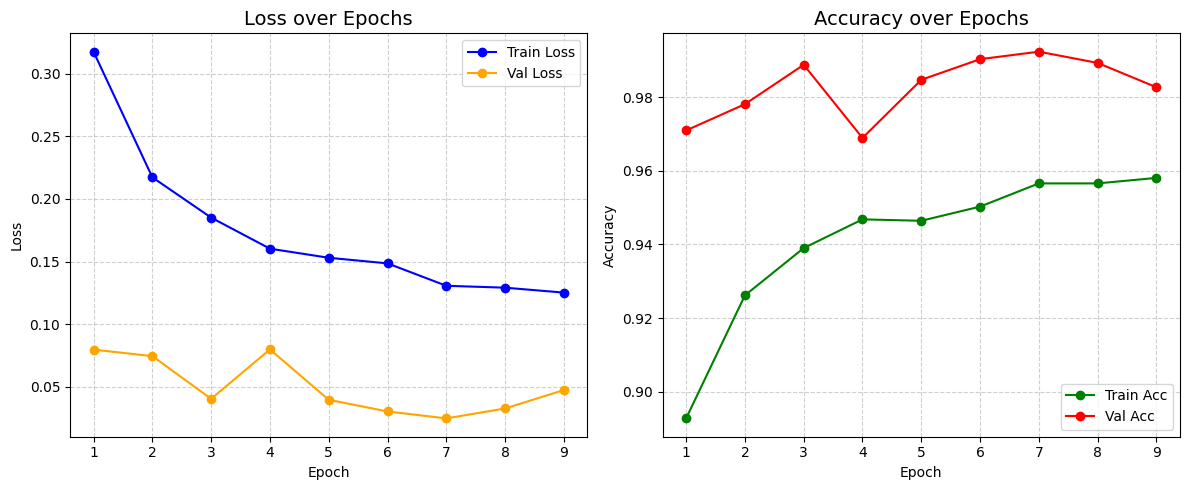

In [ ]:
train_epoch(9)
validate_epoch(9)
plot_metrics()


🚀 --- TRAIN: Epoch 10 ---
📈 Train Loss: 0.1231 | Train Acc: 0.9590

🔬 --- VALIDATE: Epoch 10 ---
📉 Val Loss:   0.0295 | Val Acc:   0.9888
⚠️ No improvement in validation loss this epoch.


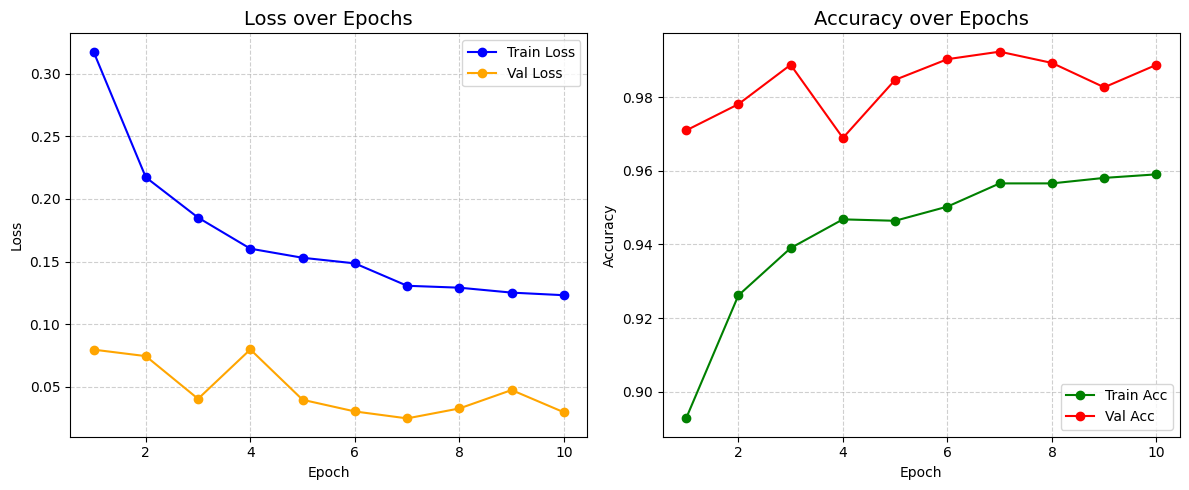

In [ ]:
train_epoch(10)
validate_epoch(10)
plot_metrics()


🚀 --- TRAIN: Epoch 11 ---
📈 Train Loss: 0.1198 | Train Acc: 0.9609

🔬 --- VALIDATE: Epoch 11 ---
📉 Val Loss:   0.0149 | Val Acc:   0.9959
🌟 Validation loss improved! Model saved to 'best_disaster_model.pth'.


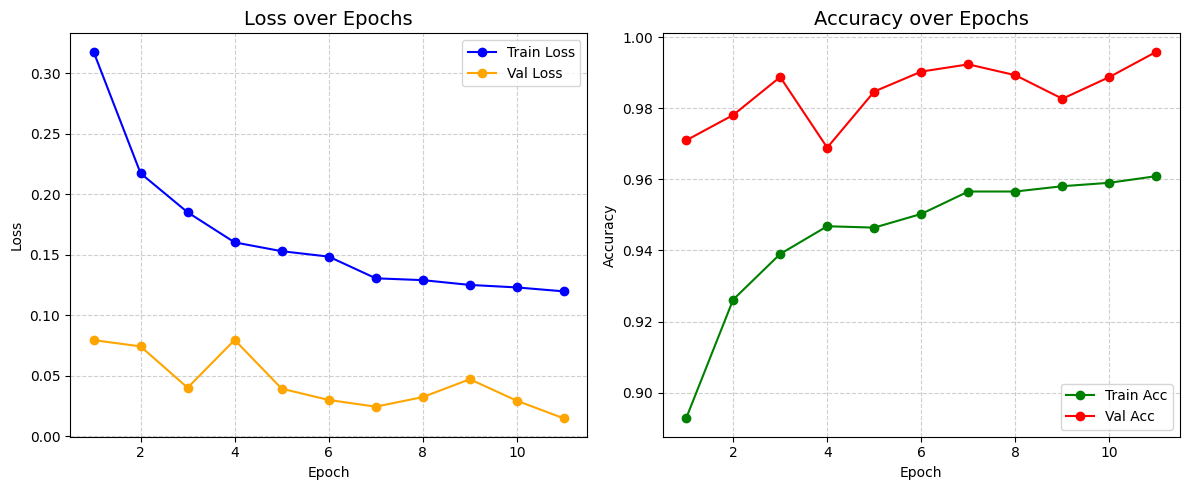

In [ ]:
train_epoch(11)
validate_epoch(11)
plot_metrics()


🚀 --- TRAIN: Epoch 12 ---
📈 Train Loss: 0.1031 | Train Acc: 0.9658

🔬 --- VALIDATE: Epoch 12 ---
📉 Val Loss:   0.0176 | Val Acc:   0.9944
⚠️ No improvement in validation loss this epoch.


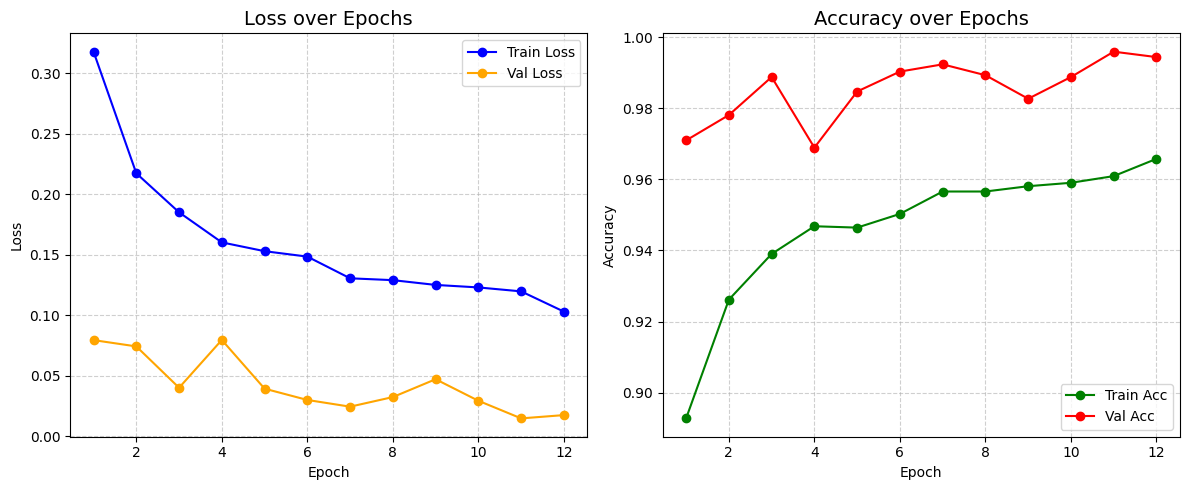

In [ ]:
train_epoch(12)
validate_epoch(12)
plot_metrics()


🚀 --- TRAIN: Epoch 13 ---
📈 Train Loss: 0.1138 | Train Acc: 0.9629

🔬 --- VALIDATE: Epoch 13 ---
📉 Val Loss:   0.0136 | Val Acc:   0.9959
🌟 Validation loss improved! Model saved to 'best_disaster_model.pth'.


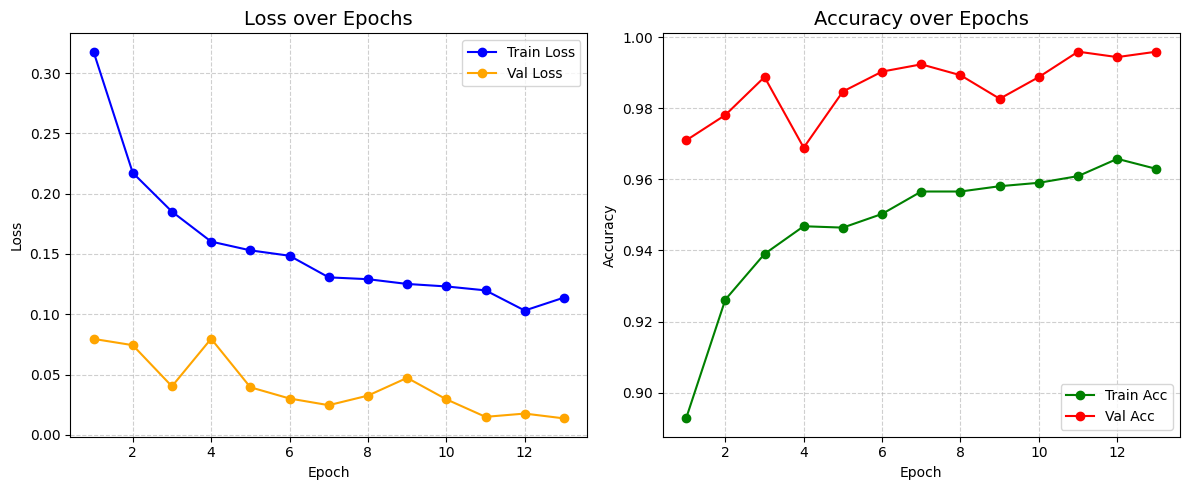

In [ ]:
train_epoch(13)
validate_epoch(13)
plot_metrics()


🚀 --- TRAIN: Epoch 14 ---
📈 Train Loss: 0.1169 | Train Acc: 0.9619

🔬 --- VALIDATE: Epoch 14 ---
📉 Val Loss:   0.0419 | Val Acc:   0.9827
⚠️ No improvement in validation loss this epoch.


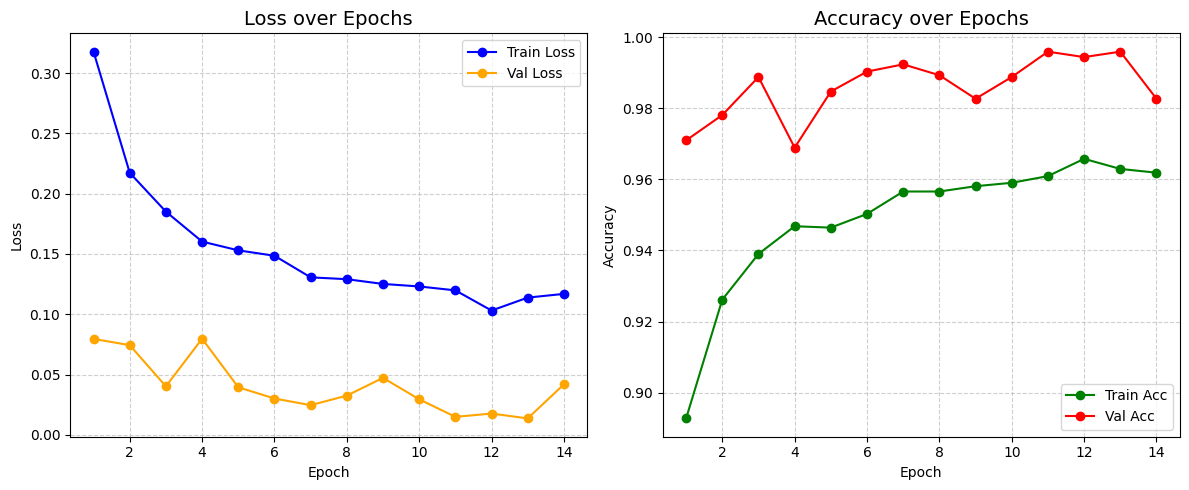

In [ ]:
train_epoch(14)
validate_epoch(14)
plot_metrics()


🚀 --- TRAIN: Epoch 15 ---
📈 Train Loss: 0.0973 | Train Acc: 0.9677

🔬 --- VALIDATE: Epoch 15 ---
📉 Val Loss:   0.0118 | Val Acc:   0.9975
🌟 Validation loss improved! Model saved to 'best_disaster_model.pth'.


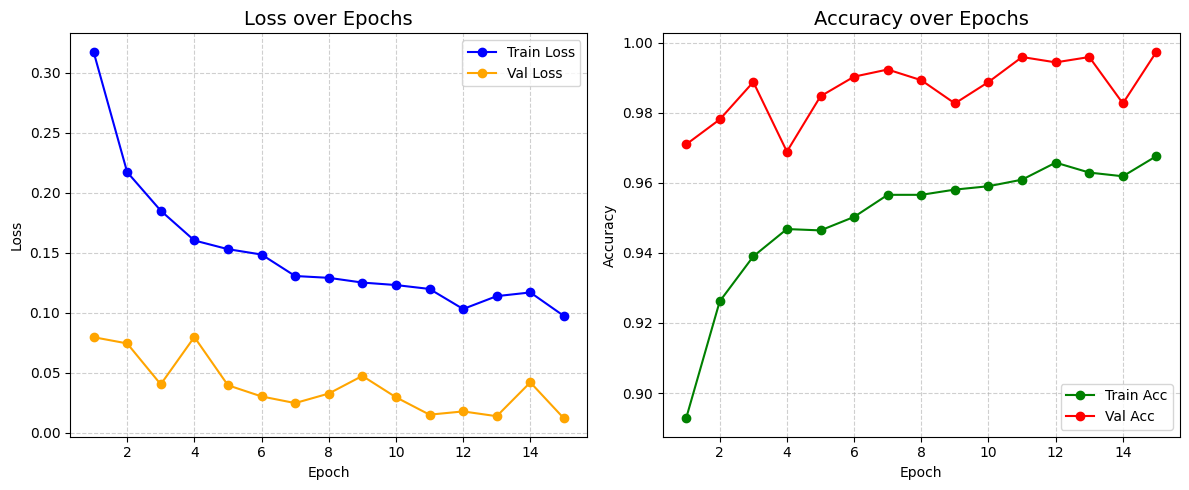

In [ ]:
train_epoch(15)
validate_epoch(15)
plot_metrics()


🚀 --- TRAIN: Epoch 16 ---
📈 Train Loss: 0.0924 | Train Acc: 0.9690

🔬 --- VALIDATE: Epoch 16 ---
📉 Val Loss:   0.0049 | Val Acc:   0.9985
🌟 Validation loss improved! Model saved to 'best_disaster_model.pth'.


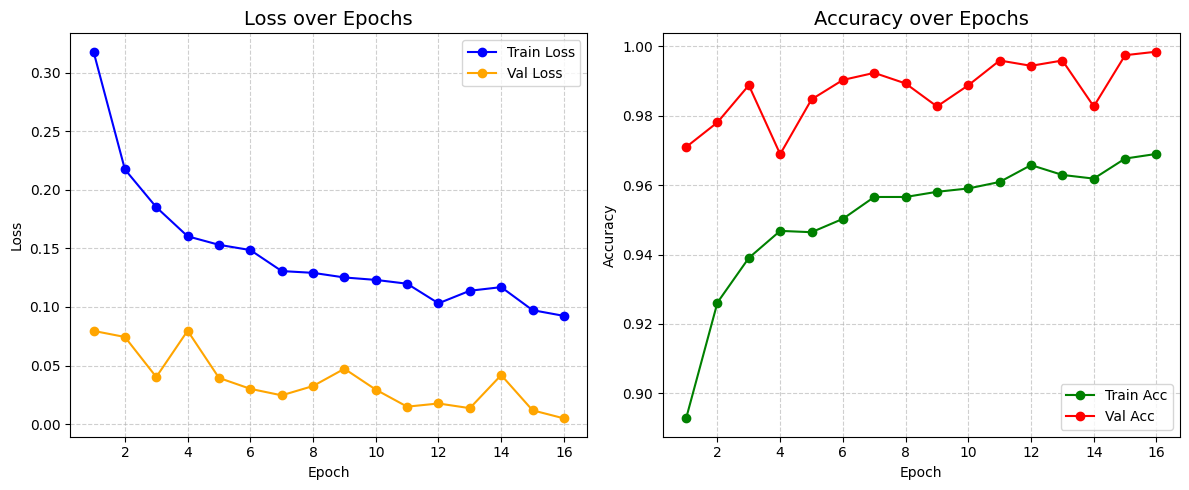

In [ ]:
train_epoch(16)
validate_epoch(16)
plot_metrics()


🚀 --- TRAIN: Epoch 17 ---
📈 Train Loss: 0.0836 | Train Acc: 0.9721

🔬 --- VALIDATE: Epoch 17 ---
📉 Val Loss:   0.0078 | Val Acc:   0.9990
⚠️ No improvement in validation loss this epoch.


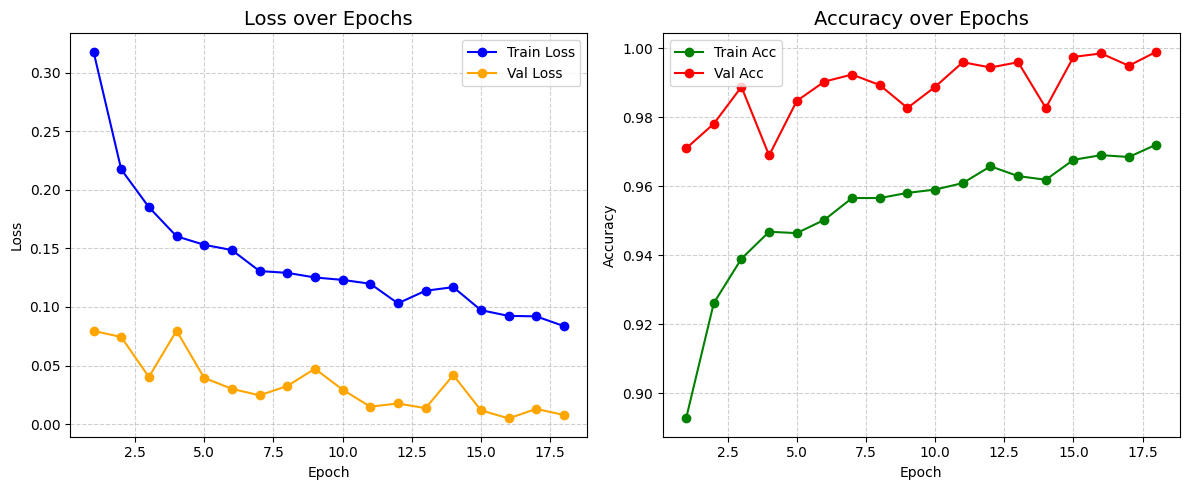

In [ ]:
train_epoch(17)
validate_epoch(17)
plot_metrics()


🚀 --- TRAIN: Epoch 18 ---
📈 Train Loss: 0.1046 | Train Acc: 0.9659

🔬 --- VALIDATE: Epoch 18 ---
📉 Val Loss:   0.0104 | Val Acc:   0.9969
⚠️ No improvement in validation loss this epoch.


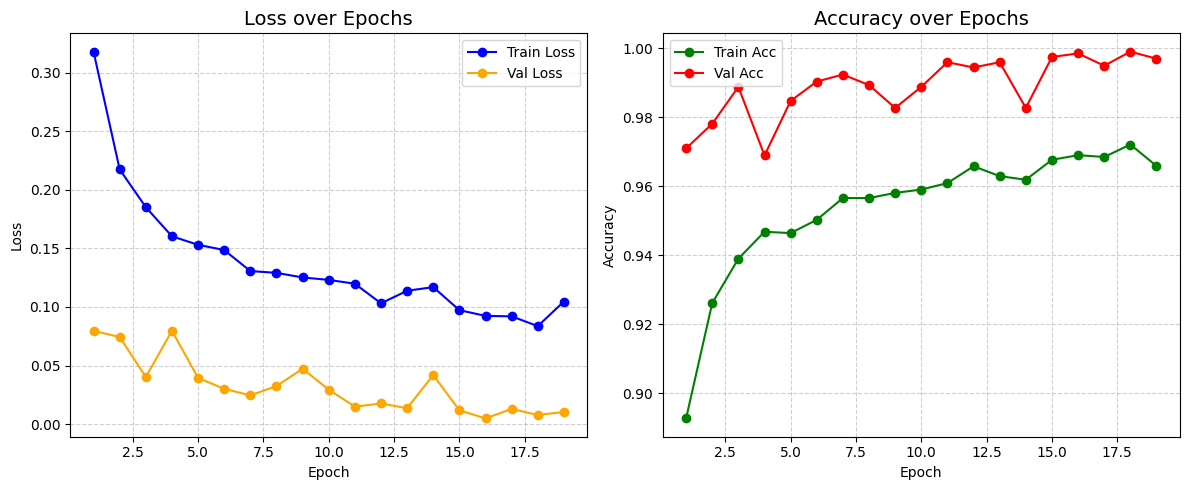

In [ ]:
train_epoch(18)
validate_epoch(18)
plot_metrics()


🚀 --- TRAIN: Epoch 19 ---
📈 Train Loss: 0.0900 | Train Acc: 0.9702

🔬 --- VALIDATE: Epoch 19 ---
📉 Val Loss:   0.0081 | Val Acc:   0.9980
⚠️ No improvement in validation loss this epoch.


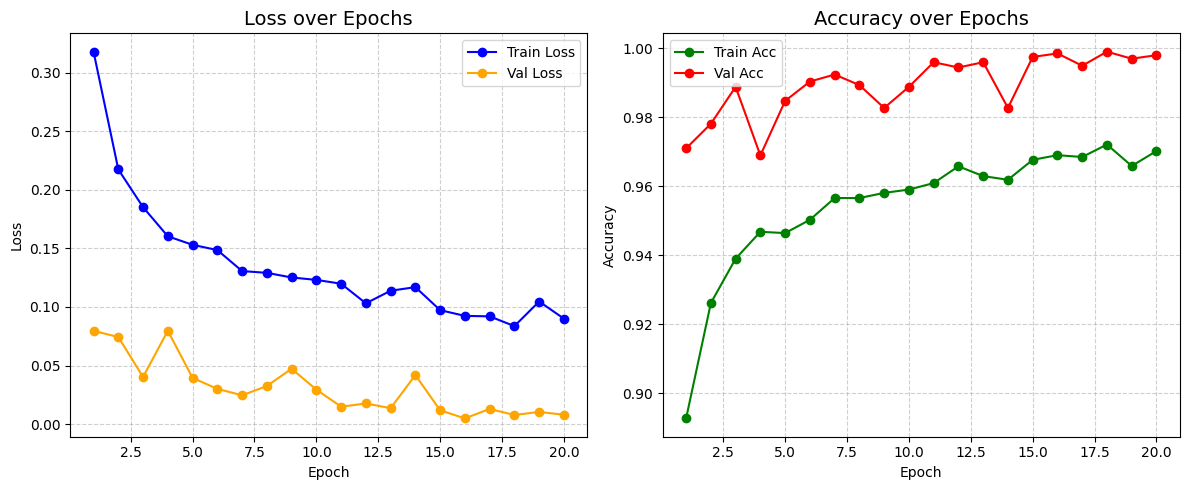

In [ ]:
train_epoch(19)
validate_epoch(19)
plot_metrics()


🚀 --- TRAIN: Epoch 20 ---
📈 Train Loss: 0.0614 | Train Acc: 0.9802

🔬 --- VALIDATE: Epoch 20 ---
📉 Val Loss:   0.0025 | Val Acc:   1.0000
🌟 Validation loss improved! Model saved to 'best_disaster_model.pth'.


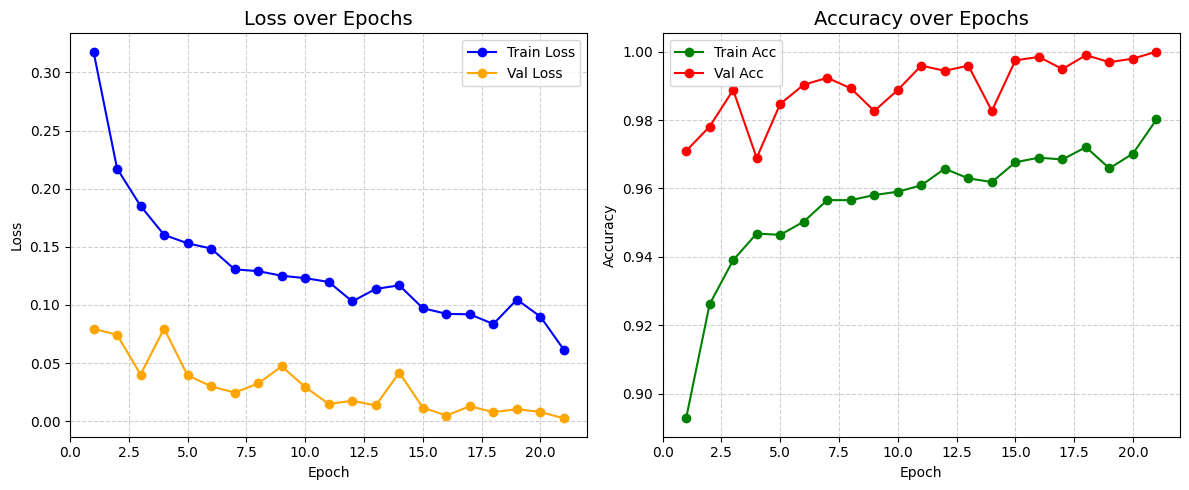

In [ ]:
train_epoch(20)
validate_epoch(20)
plot_metrics()

In [ ]:
# Save the entire model object, not just state_dict
torch.save(model, 'final_disaster_model.pth')

In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# 1. Define the prediction function
def predict_image(image_path, model, transform, classes):
    model.eval() # Set model to evaluation mode

    # Load and preprocess the image
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device) # Add batch dimension

    # Run prediction
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted_idx = torch.max(probabilities, 1)

    predicted_class = classes[predicted_idx.item()]
    confidence_score = confidence.item() * 100

    # Display results
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class} ({confidence_score:.2f}%)")
    plt.axis('off')
    plt.show()

# 2. Use it!
# Replace 'path_to_your_new_image.jpg' with an actual file path
# predict_image('path_to_your_new_image.jpg', model, val_transforms, train_dataset.classes)


### **1. The Industry Standard: ResNet (ResNet-18 or ResNet-50)**

ResNet (Residual Networks) is the workhorse of modern computer vision. It introduced "skip connections" that allow deep networks to train effectively without forgetting early information.

* **Pros:** * Incredibly stable and easy to train.
* The "baseline" model every researcher uses; if your dataset works well on ResNet, it is a good dataset.
* Great balance between speed and high accuracy.


* **Cons:** * Larger and slower than MobileNet.
* An older architecture (2015), so it isn't quite as perfectly optimized as newer models.



### **2. The Optimizer: EfficientNet (EfficientNet-B0 to B7)**

EfficientNet was designed by an AI that searched for the perfect mathematical balance between network depth, width, and image resolution. **B0** is the smallest and fastest, scaling up to **B7** (the largest and most accurate).

* **Pros:** * Incredible accuracy-to-size ratio. EfficientNet-B0 is similar in size to ResNet-18 but is often much more accurate.
* Highly scalable (you can just change `b0` to `b3` if you want higher accuracy and have the GPU power).


* **Cons:** * Can be a bit more memory-hungry during training than ResNet.
* Slightly slower inference time on basic CPUs compared to MobileNet.



### **3. The Heavyweight SOTA: Vision Transformer (ViT)**

ViT completely ditches standard convolutional layers (CNNs) and instead treats patches of an image like words in a sentence, using the same "Attention" mechanism that powers ChatGPT.

* **Pros:** * State-of-the-art (SOTA) accuracy on complex datasets.
* Excellent at understanding the "global context" of an image (e.g., realizing that a fire engine and a collapsed building in different corners of an image mean a disaster).


* **Cons:** * Massive file size and requires a powerful GPU to train.
* Data hungry. Transformers usually require vastly more data than CNNs to learn effectively (though using pre-trained weights heavily mitigates this).



### **4. The Direct Upgrade: MobileNetV3 (Large or Small)**

If you want to stay in the lightweight category for a mobile app deployment but want a slight bump in performance, MobileNetV3 is the successor to your current model.

* **Pros:** * Hardware-aware architecture (optimized specifically to run fast on mobile CPUs).
* Slightly better accuracy than V2 with fewer parameters.


* **Cons:** * Still sacrifices overall top-end accuracy in favor of speed.

---

### **Quick Comparison Matrix**

| Model Architecture | Size/Parameters | Speed (Inference) | Best Used For... |
| --- | --- | --- | --- |
| **MobileNetV2** | ~3.5 Million | Extremely Fast | Edge devices, mobile phones, weak CPUs. |
| **ResNet-18** | ~11.7 Million | Fast | Establishing a solid, reliable baseline. |
| **EfficientNet-B0** | ~5.3 Million | Fast | Getting the best accuracy with limited compute. |
| **ResNet-50** | ~25.6 Million | Moderate | High-accuracy general-purpose classification. |
| **ViT-Base** | ~86 Million | Slow | Chasing the absolute highest accuracy possible. |

---

### **How to Swap Them in Your Code**

Because you built a highly modular PyTorch pipeline, changing the model is incredibly easy. You just have to change the `MODEL SETUP` section.

**Important Note:** Different models name their final classification layer differently. MobileNet uses `.classifier`, ResNet uses `.fc` (fully connected), and ViT uses `.heads`.

**Example: Swapping to ResNet-18**

```python
# 1. Load the new model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 2. Rebuild the final layer (ResNet uses 'fc' instead of 'classifier')
num_classes = len(train_dataset.classes)
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(model.fc.in_features, num_classes) # Notice we use in_features here
)
model = model.to(device)

```

**Example: Swapping to EfficientNet-B0**

```python
# 1. Load the new model
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# 2. Rebuild the final layer (EfficientNet uses 'classifier' like MobileNet)
num_classes = len(train_dataset.classes)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

model = model.to(device)

```

When using the **Google Colab Free Tier**, your biggest constraints are the **GPU RAM (VRAM)** and the **System RAM**. Google currently provides the T4 GPU, which has **16GB of VRAM**. This is a solid amount for training, but it isn't unlimited.

Here is how those models perform on the Colab Free Tier:

### **1. MobileNetV2 / V3 (Highly Recommended)**

* **Compatibility:** Excellent.
* **Performance:** Extremely lightweight. You will rarely hit "Out of Memory" (OOM) errors. You can increase your `batch_size` significantly (e.g., to 64 or 128) to speed up training.
* **Colab Experience:** You will have plenty of headroom for your OS and other background processes.

### **2. ResNet-18 / ResNet-50 (Excellent Choice)**

* **Compatibility:** Excellent.
* **Performance:** ResNet-18 is very fast; ResNet-50 is a great "sweet spot" for accuracy. Both fit easily into 16GB of VRAM.
* **Colab Experience:** You can train these for hours without hitting memory limits. ResNet-50 is arguably the most popular model to train in Colab.

### **3. EfficientNet-B0 to B3 (Highly Recommended)**

* **Compatibility:** Good.
* **Performance:** EfficientNet-B0 and B1 are very efficient. Once you move to **B4 or higher**, the VRAM usage spikes.
* **Colab Experience:** B0-B2 will be perfectly happy. B4+ might require you to lower your batch size (e.g., to 8 or 16) to prevent crashes.

### **4. Vision Transformers (ViT) (Use with Caution)**

* **Compatibility:** Fair.
* **Performance:** ViT-Base has many parameters and is memory-intensive.
* **Colab Experience:** You can run it, but you will likely have to use a small `batch_size` (like 8 or even 4). If you want to use the larger `ViT-Large` models, you will almost certainly run into OOM errors on the free tier unless you use advanced techniques like Gradient Accumulation.

---

### **Summary Table: Colab Free Tier Suitability**

| Model | Batch Size (on Free T4) | Suitability |
| --- | --- | --- |
| **MobileNetV2** | 64 - 128 | ⭐⭐⭐⭐⭐ |
| **ResNet-18** | 64 - 128 | ⭐⭐⭐⭐⭐ |
| **ResNet-50** | 32 - 64 | ⭐⭐⭐⭐⭐ |
| **EfficientNet-B0** | 32 - 64 | ⭐⭐⭐⭐⭐ |
| **EfficientNet-B4** | 8 - 16 | ⭐⭐⭐ |
| **ViT-Base** | 4 - 8 | ⭐⭐ |

---

### **Crucial Tips for Colab Free Tier**

1. **Watch your Batch Size:** If you get a `RuntimeError: CUDA out of memory`, do not panic. Simply stop your training, decrease the `batch_size` (e.g., from 32 down to 16), and restart your kernel.
2. **Use `num_workers=2`:** We already did this, but it is critical. Higher values (like 4 or 8) consume your limited System RAM, which can crash the Colab notebook before the GPU even gets the data.
3. **Use `Gradient Accumulation`:** If you want to train a "Heavy" model (like a ViT) but keep the accuracy of a large batch, you can use gradient accumulation. This allows you to simulate a large batch size by running multiple small batches before updating the weights.
* *Example:* If you want a batch size of 32 but your GPU only fits 8, set `batch_size=8` and run `optimizer.step()` only every 4 batches.



**Would you like to try swapping your `model` architecture to ResNet-50 or EfficientNet-B0 to see if you get better accuracy on your disaster dataset?**

For a disaster image classification task, your primary goal is to identify distinct, complex visual features—such as structural damage, fire patterns, flood water, or debris. Because disasters involve varied textures and shapes (e.g., the difference between a smoke plume and a water wave), **ResNet-50** or **EfficientNet-B0** are the best choices for your Colab environment.

Here is why these models are better suited for your specific use case than MobileNetV2:

### **1. Why ResNet-50? (The "Feature Expert")**

ResNet-50 is the gold standard for transfer learning in disaster datasets.

* **Deep Feature Extraction:** Because it is deeper than MobileNet, it is much better at picking up subtle structural cues—like the difference between a roof that has collapsed versus one that is just stained.
* **Compatibility:** It is perfectly sized for Colab. You will have no memory issues, and it trains very quickly.
* **Transfer Learning:** It was trained on ImageNet, which contains many outdoor and building-related categories, making it a "natural" at recognizing disaster scenes.

### **2. Why EfficientNet-B0? (The "Balanced Specialist")**

If your dataset contains many images that look similar (e.g., different types of flood water), EfficientNet is arguably superior.

* **Global Context:** EfficientNet is better at looking at the "whole image" to understand the context. MobileNet is designed to be efficient by discarding some information; EfficientNet is designed to keep as much useful information as possible.
* **Accuracy Ceiling:** It generally achieves higher accuracy on complex, real-world scenes than MobileNet.

---

### **Recommendation for Your Pipeline**

I recommend switching to **ResNet-50**. It is the most robust model for this type of project. It handles the nuances of disaster imagery better than MobileNetV2 while remaining very stable in the Colab Free Tier.

**Here is the quick code swap for your "MODEL SETUP" section:**

```python
# Replace your current model setup with this:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# ResNet-50 uses 'fc' for the final classification layer
num_classes = len(train_dataset.classes)
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(model.fc.in_features, num_classes)
)

model = model.to(device)

```

### **Why this helps you LEARN better:**

By moving to a slightly larger model, you are learning how to balance **Model Capacity** vs. **Hardware Constraints**. Disaster classification is a "fine-grained" task—meaning small differences in pixels make a huge difference in the outcome. A model like ResNet-50 has more "parameters" (neurons/weights), which allows it to store more complex patterns, like the specific jagged edges of rubble or the distinct gradient of fire smoke.

**One final tip:** Since you are doing disaster classification, ensure your `train_transforms` include `RandomResizedCrop(224)`. This forces the model to look at zoomed-in sections of the disaster, which helps it learn that "rubble" is rubble even if it only occupies a small part of the frame.

Would you like to swap your model to ResNet-50 now and run a test epoch to see if your Validation Accuracy improves?